# ATLAS — Whisper Transcription on GTSinger

Note: this notebook uses the **exact same** normalisation and WER-PER pipeline as the other two models that we previously used (FireRedASR and wav2vec2) so results are directly comparable:
- Tag removal: `re.sub(r"<[^>]+>", "", text)` — strips `<AP>`, `<SP>`, any angle-bracket label
- Phoneme conversion: `g2p_en` (same library as FireRedASR and wav2vec2)
- WER: `jiwer.wer()` (same function)
- Output column: `asr_hypothesis` (same name)

## 1. Mount Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Paths & Configuration

In [ ]:
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
PROJECT_DIR = Path("/content/drive/Othercomputers/Il mio laptop/Desktop/Music Information Retrieval/Project/atlas")
# ══════════════════════════════════════════════════════════════════════════════

# Inventory CSV produced by dataset analysis notebook 
INVENTORY_CSV  = PROJECT_DIR / "whisper_results" / "utterance_inventory.csv"

# Whisper weights cached on Drive
WHISPER_CACHE  = PROJECT_DIR / "whisper_weights"
WHISPER_CACHE.mkdir(parents=True, exist_ok=True)

# Results, put in the same folder as FireRedASR and wav2vec for easy comparison
DRIVE_RESULTS  = PROJECT_DIR / "results"
DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)

# Local working dir
LOCAL          = Path("/content/atlas_whisper")
RESULTS_DIR    = LOCAL / "results"
LOCAL.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Which models to run ───────────────────────────────────────────────────────
WHISPER_MODELS = [
    "small",        # fast sanity check
    "large-v2",     # main evaluation
    "large-v3",   # uncomment for latest
]

# ── Groups to transcribe (same as FireRedASR/wav2vec) ─────────────────────────
SINGING_GROUPS = {"Breathy_Group","Glissando_Group","Vibrato_Group",
                  "Falsetto_Group","Mixed_Voice_Group","Pharyngeal_Group",
                  "Control_Group"}

# ── Cap for quick testing (set None for full run) ─────────────────────────────
MAX_UTTERANCES = None   # set to e.g. 50 for a quick test

print(f"INVENTORY_CSV : {'OK' if INVENTORY_CSV.exists() else 'NOT FOUND'} | {INVENTORY_CSV}")
print(f"DRIVE_RESULTS : {DRIVE_RESULTS}")
print(f"Models        : {WHISPER_MODELS}")
print(f"MAX_UTTERANCES: {MAX_UTTERANCES}")

INVENTORY_CSV : OK | /content/drive/Othercomputers/Il mio laptop/Desktop/Music Information Retrieval/Project/atlas/whisper_results/utterance_inventory.csv
DRIVE_RESULTS : /content/drive/Othercomputers/Il mio laptop/Desktop/Music Information Retrieval/Project/atlas/results
Models        : ['large-v2', 'large-v3']
MAX_UTTERANCES: None


## 3. Install Dependencies

In [4]:
!pip install -q openai-whisper jiwer g2p_en pandas numpy matplotlib seaborn tqdm
!apt-get -qq install -y ffmpeg

import nltk
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("cmudict", quiet=True)

import whisper, torch, pandas as pd, numpy as np
import re, os, shutil, time
from pathlib import Path
from tqdm.notebook import tqdm
from g2p_en import G2p
from jiwer import wer as jiwer_wer, process_words
import matplotlib.pyplot as plt
import seaborn as sns

g2p    = G2p()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("No GPU — large-v2 will be very slow. Use Runtime > Change runtime type > T4 GPU.")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
print(f"Whisper models available: {whisper.available_models()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 48.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 129.0 MB/s eta 0:00:00


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.1 GB
Whisper models available: ['tiny.en', 'tiny', 'base.en', 'base', 'small.en', 'small', 'medium.en', 'medium', 'large-v1', 'large-v2', 'large-v3', 'large', 'large-v3-turbo', 'turbo']


In [ ]:
!pip install praatio
from pathlib import Path
from praatio import textgrid as ptextgrid
from tqdm.notebook import tqdm
import pandas as pd, re

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_DIR  = Path("/content/drive/Othercomputers/Il mio laptop/Desktop/Music Information Retrieval/Project/atlas")
ENGLISH_RAW  = PROJECT_DIR / "English_raw"
OLD_META_CSV = PROJECT_DIR / "metadata2" / "atlas_english_metadata.csv"  # existing one used by FireRedASR
NEW_META_CSV = PROJECT_DIR / "metadata2" / "atlas_english_metadata_REBUILT.csv"

# ── Find data root ─────────────────────────────────────────────────────────────
def find_english_root(base):
    for p in sorted(base.rglob("*")):
        if p.is_dir() and any(s in p.name for s in ["EN-Tenor","EN-Alto","EN-Soprano","EN-Bass"]):
            return p.parent
        if p.is_dir() and p.name.lower() == "english":
            return p
    return base

ENGLISH_ROOT = find_english_root(ENGLISH_RAW)
print(f"English root: {ENGLISH_ROOT}")

# ── Mappings (from real folder names) ─────────────────────────────────────────
ALL_GROUPS = {
    "Breathy_Group","Glissando_Group","Vibrato_Group",
    "Falsetto_Group","Mixed_Voice_Group","Pharyngeal_Group",
    "Control_Group","Paired_Speech_Group",
}
GROUP_LABEL = {
    "Control_Group":       "control",
    "Paired_Speech_Group": "speech",
}
for g in ALL_GROUPS - {"Control_Group","Paired_Speech_Group"}:
    GROUP_LABEL[g] = "technique"

TECHNIQUE_LABEL = {
    "Breathy":                  "breathy",
    "Glissando":                "glissando",
    "Vibrato":                  "vibrato",
    "Mixed_Voice_and_Falsetto": "mixed_falsetto",
    "Pharyngeal":               "pharyngeal",
}

SKIP_LABELS = {
    "","sp","sil","SIL","<eps>","spn",
    "<SP>","SP","<AP>","AP","<br>","BR",
}

def extract_gt_lyrics(tg_path: Path) -> str:
    """Extract word-tier lyrics, filtering silence and breath markers."""
    try:
        tg = ptextgrid.openTextgrid(str(tg_path), includeEmptyIntervals=False)
        for tier_name in tg.tierNames:
            if "word" in tier_name.lower():
                words = [e.label.strip() for e in tg.getTier(tier_name).entries
                         if e.label.strip() not in SKIP_LABELS]
                return " ".join(words)
    except Exception:
        pass
    return ""

def normalise_text(text: str) -> str:
    if not isinstance(text, str): return ""
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"[^a-z ]", "", text.lower())
    return re.sub(r"\s+", " ", text).strip()


# ── Walk English_raw and build records ────────────────────────────────────────
records = []
wav_files = [w for w in ENGLISH_ROOT.rglob("*.wav") if not w.name.startswith(".")]
print(f"Found {len(wav_files):,} WAV files")

for wav in tqdm(wav_files, desc="Building metadata"):
    group_folder     = wav.parent.name                      # e.g. Breathy_Group
    song             = wav.parent.parent.name               # e.g. "all is found"
    technique_folder = wav.parent.parent.parent.name        # e.g. "Breathy"
    singer_id        = wav.parent.parent.parent.parent.name # e.g. "EN-Alto-1"

    if group_folder not in ALL_GROUPS:
        continue

    technique   = TECHNIQUE_LABEL.get(technique_folder, technique_folder.lower())
    group       = GROUP_LABEL.get(group_folder, "unknown")

    tg_path   = wav.with_suffix(".TextGrid")
    gt_lyrics = extract_gt_lyrics(tg_path) if tg_path.exists() else ""

    # <singer_id>__<technique>__<group>__<song>__<stem>
    clean_name = f"{singer_id}__{technique}__{group}__{song}__{wav.stem}".replace(" ", "_")

    records.append({
        "clean_name":  clean_name,
        "singer_id":   singer_id,
        "technique":   technique,
        "group":       group,
        "group_folder":group_folder,
        "song":        song,
        "wav_path":    str(wav),
        "tg_path":     str(tg_path) if tg_path.exists() else None,
        "has_tg":      tg_path.exists(),
        "gt_lyrics":   gt_lyrics,
        "gt_lyrics_clean": normalise_text(gt_lyrics),
    })

new_meta = pd.DataFrame(records)
new_meta.to_csv(NEW_META_CSV, index=False)
print(f"\n✅ Rebuilt metadata: {len(new_meta):,} rows -> {NEW_META_CSV.name}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 9.5 MB/s eta 0:00:00
English root: /content/drive/Othercomputers/Il mio laptop/Desktop/Music Information Retrieval/Project/atlas/English_raw/English
Found 6,892 WAV files


Building metadata:   0%|          | 0/6892 [00:00<?, ?it/s]


✅ Rebuilt metadata: 6,892 rows -> atlas_english_metadata_REBUILT.csv


In [6]:
old_meta = pd.read_csv(OLD_META_CSV) if OLD_META_CSV.exists() else None

print("=" * 65)
print("  METADATA COMPARISON")
print("=" * 65)

print(f"\n  Old ({OLD_META_CSV.name}): {len(old_meta):,} rows" if old_meta is not None else "\n  Old: NOT FOUND")
print(f"  New (rebuilt from English_raw): {len(new_meta):,} rows")
if old_meta is not None:
    print(f"  Difference: {len(new_meta) - len(old_meta):+,} rows")

if old_meta is not None:

    # ── Columns ────────────────────────────────────────────────────────────────
    print(f"\n  Old columns: {list(old_meta.columns)}")
    print(f"  New columns: {list(new_meta.columns)}")

    # ── Group breakdown ────────────────────────────────────────────────────────
    print("\n── By group ──────────────────────────────────────────────────")
    old_grp_col = "group" if "group" in old_meta.columns else "atlas_group"
    for label, df, col in [("OLD", old_meta, old_grp_col), ("NEW", new_meta, "group")]:
        print(f"\n  {label}:")
        print(df.groupby(col).size().rename("n").sort_index().to_string())

    # ── Singers ────────────────────────────────────────────────────────────────
    print("\n── Singers ───────────────────────────────────────────────────")
    old_s = set(old_meta["singer_id"].unique())
    new_s = set(new_meta["singer_id"].unique())
    print(f"  Old: {sorted(old_s)}")
    print(f"  New: {sorted(new_s)}")
    if old_s != new_s:
        print(f"  Only in NEW : {sorted(new_s - old_s)}")
        print(f"  Only in OLD : {sorted(old_s - new_s)}")
    else:
        print("  Same singers in both.")

    # ── Techniques ─────────────────────────────────────────────────────────────
    print("\n── Techniques ────────────────────────────────────────────────")
    old_t = set(old_meta["technique"].unique())
    new_t = set(new_meta["technique"].unique())
    print(f"  Old: {sorted(old_t)}")
    print(f"  New: {sorted(new_t)}")
    if old_t != new_t:
        print(f"  Only in NEW: {sorted(new_t - old_t)}")
        print(f"  Only in OLD: {sorted(old_t - new_t)}")

    # ── GT lyrics coverage ─────────────────────────────────────────────────────
    print("\n── GT lyrics coverage ────────────────────────────────────────")
    old_gt_col = "gt_lyrics" if "gt_lyrics" in old_meta.columns else None
    if old_gt_col:
        old_with = (old_meta[old_gt_col].str.len() > 0).sum()
        new_with = (new_meta["gt_lyrics"].str.len() > 0).sum()
        print(f"  Old: {old_with:,} / {len(old_meta):,}  ({old_with/len(old_meta)*100:.1f}%)")
        print(f"  New: {new_with:,} / {len(new_meta):,}  ({new_with/len(new_meta)*100:.1f}%)")

        # Check for <AP>/<SP> still in old
        if old_gt_col:
            old_tagged = old_meta[old_gt_col].str.contains(r"<[A-Z]+>", na=False).sum()
            new_tagged = new_meta["gt_lyrics"].str.contains(r"<[A-Z]+>", na=False).sum()
            print(f"\n  Rows with <AP>/<SP> tags in old lyrics: {old_tagged:,}")
            print(f"  Rows with <AP>/<SP> tags in new lyrics: {new_tagged:,}  (should be 0)")

    # ── Per singer × group count ───────────────────────────────────────────────
    print("\n── Utterances per singer × group ─────────────────────────────")
    for label, df, col in [("OLD", old_meta, old_grp_col), ("NEW", new_meta, "group")]:
        print(f"\n  {label}:")
        print(df.groupby(["singer_id", col]).size()
              .rename("n").reset_index().to_string(index=False))

  METADATA COMPARISON

  Old (atlas_english_metadata.csv): 6,892 rows
  New (rebuilt from English_raw): 6,892 rows
  Difference: +0 rows

  Old columns: ['singer_id', 'technique', 'group', 'song_id', 'wav_path', 'tg_path', 'xml_path', 'has_textgrid', 'has_musicxml', 'gt_lyrics', 'clean_name']
  New columns: ['clean_name', 'singer_id', 'technique', 'group', 'group_folder', 'song', 'wav_path', 'tg_path', 'has_tg', 'gt_lyrics', 'gt_lyrics_clean']

── By group ──────────────────────────────────────────────────

  OLD:
group
control      2065
speech       2065
technique    2762

  NEW:
group
control      2065
speech       2065
technique    2762

── Singers ───────────────────────────────────────────────────
  Old: ['EN-Alto-1', 'EN-Alto-2', 'EN-Tenor-1']
  New: ['EN-Alto-1', 'EN-Alto-2', 'EN-Tenor-1']
  Same singers in both.

── Techniques ────────────────────────────────────────────────
  Old: ['breathy', 'glissando', 'mixed_voice', 'pharyngeal', 'vibrato']
  New: ['breathy', 'glissando', 

## 4. Text Normalisation & Phoneme Conversion

**Identical to FireRedASR and wav2vec2 notebooks** so WER/PER are directly comparable.

In [7]:
def normalise_text(text: str) -> str:
    """
    Identical to clean_text() in FireRedASR and wav2vec2:
      1. Strip all angle-bracket tags including content (<AP>, <SP>, etc.)
      2. Lowercase
      3. Remove all non a-z characters
      4. Collapse whitespace
    """
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", "", text)    # strips <AP>, <SP>, any tag
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def text_to_phonemes(text: str) -> str:
    """
    Convert text to phoneme sequence using g2p_en.
    Identical to text_to_phonemes() in FireRedASR and wav2vec2.
    """
    text = normalise_text(text)
    if not text:
        return ""
    phonemes = g2p(text)
    return " ".join([p for p in phonemes if p.strip() and p != " "])


def compute_wer_per(df: pd.DataFrame,
                    ref_col: str = "gt_lyrics_clean",
                    hyp_col: str = "asr_hypothesis") -> pd.DataFrame:
    """
    Compute WER and PER using jiwer.wer() — same as FireRedASR/wav2vec2.
    Also adds S/D/I breakdown for extra Whisper-specific analysis.
    """
    wer_list, per_list = [], []
    S_list, D_list, I_list, nref_list = [], [], [], []

    for _, row in df.iterrows():
        gt  = str(row.get(ref_col, ""))
        hyp = normalise_text(str(row.get(hyp_col, "")))

        if gt:
            w = jiwer_wer(gt, hyp)
            out = process_words(gt, hyp)
            S_list.append(out.substitutions)
            D_list.append(out.deletions)
            I_list.append(out.insertions)
            nref_list.append(len(gt.split()))
        else:
            w = None
            S_list.append(0); D_list.append(0)
            I_list.append(0); nref_list.append(0)
        wer_list.append(w)

        gt_ph  = text_to_phonemes(gt)
        hyp_ph = text_to_phonemes(hyp)
        per_list.append(jiwer_wer(gt_ph, hyp_ph) if gt_ph else None)

    df = df.copy()
    df["wer"]       = wer_list
    df["per"]       = per_list
    df["wer_S"]     = S_list
    df["wer_D"]     = D_list
    df["wer_I"]     = I_list
    df["wer_n_ref"] = nref_list
    return df


print("Normalisation check:")
tests = [
    "these memories rewind replay and i am far",
    "now the day bleeds <AP> into nightfall <AP> and you're not here",
    "you're my end and my beginning <AP> even when i lose i'm winning",
]
for t in tests:
    print(f"  IN : {t}")
    print(f"  OUT: {normalise_text(t)}")
    print()

Normalisation check:
  IN : these memories rewind replay and i am far
  OUT: these memories rewind replay and i am far

  IN : now the day bleeds <AP> into nightfall <AP> and you're not here
  OUT: now the day bleeds into nightfall and youre not here

  IN : you're my end and my beginning <AP> even when i lose i'm winning
  OUT: youre my end and my beginning even when i lose im winning



## 5. Load Inventory

Loads the pre-built inventory CSV.

In [8]:
assert INVENTORY_CSV.exists(), (
    f"Inventory not found at {INVENTORY_CSV}\n"
    "Run the dataset analysis notebook first to build it."
)

inventory = pd.read_csv(INVENTORY_CSV)

# Fix any remaining tags in gt_lyrics (in case inventory was saved before the fix)
inventory["gt_lyrics_clean"] = inventory["gt_lyrics"].apply(normalise_text)

# Keep only singing groups, filter empty refs
singing = inventory[
    inventory["group_folder"].isin(SINGING_GROUPS) &
    (inventory["gt_lyrics_clean"].str.len() > 0)
].copy().reset_index(drop=True)

if MAX_UTTERANCES is not None:
    singing = singing.sample(MAX_UTTERANCES, random_state=42).reset_index(drop=True)
    print(f"Capped to {MAX_UTTERANCES} utterances for quick testing.")

print(f"Total inventory rows   : {len(inventory):,}")
print(f"Singing rows with lyrics: {len(singing):,}")
print(f"Singers    : {sorted(singing['singer_id'].unique())}")
print(f"Techniques : {sorted(singing['technique'].unique())}")
print(f"Groups     : {sorted(singing['atlas_group'].unique())}")
print()

# Verify normalisation worked
tag_check = singing["gt_lyrics_clean"].str.contains(r"<[A-Z]+>", na=False).sum()
print(f"Rows still containing angle-bracket tags: {tag_check}  (should be 0)")
print()
print("Sample lyrics (normalised):")
for _, row in singing.head(3).iterrows():
    print(f"  [{row['singer_id']} / {row['technique']}] {row['gt_lyrics_clean'][:80]}")

Total inventory rows   : 4,827
Singing rows with lyrics: 3,646
Singers    : ['EN-Alto-1', 'EN-Alto-2', 'EN-Tenor-1']
Techniques : ['breathy', 'glissando', 'mixed_falsetto', 'pharyngeal', 'vibrato']
Groups     : ['control', 'technique']

Rows still containing angle-bracket tags: 0  (should be 0)

Sample lyrics (normalised):
  [EN-Alto-1 / vibrato] we shall always be as one if you love me for me
  [EN-Alto-1 / vibrato] id be sure if i knew that you loved me for me
  [EN-Alto-1 / vibrato] could i be the one youre seeking will i be the one you choose


## 6. Download & Cache Whisper Weights

First run downloads weights to local cache then copies to Drive.

In [ ]:
import subprocess, os

LOCAL_CACHE = Path("/content/whisper_weights")
LOCAL_CACHE.mkdir(parents=True, exist_ok=True)

# Official OpenAI CDN URLs for each model
WHISPER_URLS = {
    "tiny":      "https://openaipublic.azureedge.net/main/whisper/models/65147644a518d12f04e32d6f3b26facc3f8dd46e5390956a9424a650c0ce22b9/tiny.pt",
    "base":      "https://openaipublic.azureedge.net/main/whisper/models/ed3a0b6b1c0edf879ad9b11b1af5a0e6ab5db9205f891f668f8b0e6c6326e34e/base.pt",
    "small":     "https://openaipublic.azureedge.net/main/whisper/models/9ecf779972d90ba49c06d968637d720dd632c55bbf19d441fb42bf17a411e794/small.pt",
    "medium":    "https://openaipublic.azureedge.net/main/whisper/models/345ae4da62f9b3d59415adc60127b97c714f32e89e936602e85993674d08dcb1/medium.pt",
    "large-v2":  "https://openaipublic.azureedge.net/main/whisper/models/81f7c96c852ee8fc832187b0132e569d6c3065a3252ed18e56effd0b6a73e524/large-v2.pt",
    "large-v3":  "https://openaipublic.azureedge.net/main/whisper/models/e5b1a55b89c1367dacf97e3e19bfd829a01529dbfdeefa8caeb59b3f1b81dadb/large-v3.pt",
}

def ensure_weights(model_name: str):
    local_pt = LOCAL_CACHE   / f"{model_name}.pt"
    drive_pt = WHISPER_CACHE / f"{model_name}.pt"  # Drive backup

    # 1. Already on local disk, nothing to do
    if local_pt.exists():
        print(f"  [{model_name}] ✅ on local disk  ({local_pt.stat().st_size/1e9:.2f} GB)")
        return

    # 2. Copy on Drive 
    if drive_pt.exists():
        print(f"  [{model_name}] 📂 copying Drive -> local  (~30-60s for large models)...")
        result = subprocess.run(["cp", str(drive_pt), str(local_pt)])
        if result.returncode == 0:
            print(f"  [{model_name}] ✅ copied  ({local_pt.stat().st_size/1e9:.2f} GB)")
            return
        else:
            print(f"  [{model_name}] cp failed, will download instead")
            local_pt.unlink(missing_ok=True)

    # 3. Download directly from OpenAI CDN
    url = WHISPER_URLS.get(model_name)
    assert url, f"No CDN URL known for model '{model_name}'"
    print(f"  [{model_name}] 🌐 downloading from CDN (fastest)...")
    subprocess.run([
        "wget", "-q", "--show-progress",
        "-O", str(local_pt), url
    ], check=True)
    print(f"  [{model_name}] ✅ downloaded  ({local_pt.stat().st_size/1e9:.2f} GB)")

    # Save to Drive for next session so we skip download next time
    if WHISPER_CACHE.exists():
        print(f"  [{model_name}] 💾 saving to Drive for future sessions...")
        subprocess.run(["cp", str(local_pt), str(drive_pt)], check=True)
        print(f"  [{model_name}] ✅ saved to Drive")


for m in WHISPER_MODELS:
    ensure_weights(m)

  [large-v2] 📂 copying Drive -> local  (~30-60s for large models)...
  [large-v2] ✅ copied  (3.09 GB)
  [large-v3] 🌐 downloading from CDN (fastest)...
  [large-v3] ✅ downloaded  (3.09 GB)
  [large-v3] 💾 saving to Drive for future sessions...
  [large-v3] ✅ saved to Drive


## 7. Transcribe with Whisper

In [10]:
def load_whisper_model(model_name: str):
    local_pt = LOCAL_CACHE / f"{model_name}.pt"
    assert local_pt.exists(), f"Run ensure_weights('{model_name}') first"
    print(f"Loading [{model_name}] from local disk -> {DEVICE}...")
    t0 = time.time()
    model = whisper.load_model(
        model_name,
        device=DEVICE,
        download_root=str(LOCAL_CACHE)
    )
    print(f"✅ Loaded in {time.time()-t0:.0f}s")
    return model

In [11]:
def transcribe_dataset(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    print(f"\n{'='*55}")
    print(f"  Loading Whisper [{model_name}] on {DEVICE}...")
    model = load_whisper_model(model_name)
    hypotheses, times = [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"[{model_name}]"):
        t0 = time.time()
        try:
            result = model.transcribe(
                str(row["wav_path"]),
                language="en",
                task="transcribe",
                fp16=(DEVICE == "cuda"),
            )
            hyp = result["text"].strip()
        except Exception as e:
            hyp = ""
            print(f"  ERROR {Path(row['wav_path']).name}: {e}")
        hypotheses.append(hyp)
        times.append(time.time() - t0)

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    out = df.copy()
    out["asr_hypothesis"] = hypotheses          # same column name as FireRedASR/wav2vec
    out["asr_hypothesis_raw"] = hypotheses      # keep raw before normalisation
    out["transcription_time_s"] = times
    out["model"] = model_name

    total = sum(times)
    print(f"  Done: {total:.0f}s total  ({total/len(df):.1f}s/utt)")
    return out

In [12]:
all_results = []

for model_name in WHISPER_MODELS:
    # Use DRIVE_RESULTS so all models' CSVs are in the same folder
    raw_csv = DRIVE_RESULTS / f"whisper_{model_name.replace('-','_')}__singing_transcriptions_RAW.csv"

    if raw_csv.exists():
        print(f"[{model_name}] loading existing raw transcriptions...")
        df_model = pd.read_csv(raw_csv)
        df_model["model"] = model_name
    else:
        df_model = transcribe_dataset(singing, model_name)
        save_cols = ["singer_id","technique","atlas_group","group_folder",
                     "song","wav_path","gt_lyrics","gt_lyrics_clean",
                     "asr_hypothesis","asr_hypothesis_raw",
                     "transcription_time_s","model"]
        df_model[save_cols].to_csv(raw_csv, index=False)
        print(f"[{model_name}] saved raw -> {raw_csv.name}")

    all_results.append(df_model)

print("\nTranscription complete for all models.")


  Loading Whisper [large-v2] on cuda...
Loading [large-v2] from local disk -> cuda...
✅ Loaded in 27s


[large-v2]:   0%|          | 0/3646 [00:00<?, ?it/s]

  Done: 7446s total  (2.0s/utt)
[large-v2] saved raw -> whisper_large_v2__singing_transcriptions_RAW.csv

  Loading Whisper [large-v3] on cuda...
Loading [large-v3] from local disk -> cuda...
✅ Loaded in 25s


[large-v3]:   0%|          | 0/3646 [00:00<?, ?it/s]

  Done: 4487s total  (1.2s/utt)
[large-v3] saved raw -> whisper_large_v3__singing_transcriptions_RAW.csv

Transcription complete for all models.


## 8. Compute WER & PER

In [ ]:
scored_results = []

for df_model in all_results:
    model_name = df_model["model"].iloc[0]
    print(f"Scoring [{model_name}]...")

    # Ensure gt_lyrics_clean is present
    if "gt_lyrics_clean" not in df_model.columns:
        df_model["gt_lyrics_clean"] = df_model["gt_lyrics"].apply(normalise_text)

    df_scored = compute_wer_per(
        df_model,
        ref_col="gt_lyrics_clean",
        hyp_col="asr_hypothesis"
    )
    scored_results.append(df_scored)

    # Save in same format as FireRedASR/wav2vec
    scored_csv = DRIVE_RESULTS / f"whisper_{model_name.replace('-','_')}__singing_WER_PER.csv"
    save_cols = ["singer_id","technique","atlas_group","group_folder","song",
                 "gt_lyrics","gt_lyrics_clean","asr_hypothesis",
                 "wer","per","wer_S","wer_D","wer_I","wer_n_ref","model"]
    df_scored[[c for c in save_cols if c in df_scored.columns]].to_csv(scored_csv, index=False)
    print(f"  Saved -> {scored_csv.name}")

df_all = pd.concat(scored_results, ignore_index=True)
print(f"\nTotal scored rows: {len(df_all):,}")

Scoring [large-v2]...
  Saved -> whisper_large_v2__singing_WER_PER.csv
Scoring [large-v3]...
  Saved -> whisper_large_v3__singing_WER_PER.csv

Total scored rows: 7,292


## 9. Results Summary

In [14]:
summary_rows = []

for model_name in WHISPER_MODELS:
    d       = df_all[df_all["model"] == model_name].dropna(subset=["wer"])
    halluc  = (d["wer"] >= 1.0).mean()
    no_h    = d[d["wer"] < 1.0]

    row = {
        "model":             model_name,
        "n_utterances":      len(d),
        "WER%":              round(d["wer"].mean()*100, 1),
        "PER%":              round(d["per"].mean()*100, 1),
        "hallucination%":    round(halluc*100, 1),
        "WER% (no halluc)":  round(no_h["wer"].mean()*100, 1),
        "PER% (no halluc)":  round(no_h["per"].mean()*100, 1),
    }
    summary_rows.append(row)

    print(f"  [{model_name}]  n={len(d)}")
    print(f"    WER          : {row['WER%']}%")
    print(f"    PER          : {row['PER%']}%")
    print(f"    Hallucination: {row['hallucination%']}% of utterances (WER >= 100%)")
    print(f"    WER no-halluc: {row['WER% (no halluc)']}%")
    if "wer_I" in d.columns:
        avg_I = d["wer_I"].mean(); avg_n = d["wer_n_ref"].mean()
        print(f"    Avg S/D/I    : S={d['wer_S'].mean():.1f}  D={d['wer_D'].mean():.1f}  I={avg_I:.1f}")
        print(f"    Insertion rate: {avg_I/max(avg_n,1)*100:.0f}% (main driver of WER>100% on singing)")
    print()

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(DRIVE_RESULTS / "whisper_model_comparison.csv", index=False)
display(df_summary)

  [large-v2]  n=3646
    WER          : 18.8%
    PER          : 12.4%
    Hallucination: 1.2% of utterances (WER >= 100%)
    WER no-halluc: 17.2%
    Avg S/D/I    : S=1.5  D=0.4  I=0.4
    Insertion rate: 3% (main driver of WER>100% on singing)

  [large-v3]  n=3646
    WER          : 18.1%
    PER          : 11.2%
    Hallucination: 1.1% of utterances (WER >= 100%)
    WER no-halluc: 16.7%
    Avg S/D/I    : S=1.6  D=0.4  I=0.3
    Insertion rate: 2% (main driver of WER>100% on singing)



,model,n_utterances,WER%,PER%,hallucination%,WER% (no halluc),PER% (no halluc)
0,large-v2,3646,18.8,12.4,1.2,17.2,11.2
1,large-v3,3646,18.1,11.2,1.1,16.7,10.5


## 10. Breakdown by Singer / Technique / Group

In [15]:
for model_name in WHISPER_MODELS:
    d = df_all[df_all["model"] == model_name].dropna(subset=["wer"]).copy()
    d["WER%"] = (d["wer"]*100).round(1)
    d["PER%"] = (d["per"]*100).round(1)

    print(f"\n{'='*55}  [{model_name}]")

    for col, label in [
        ("singer_id",   "By Singer"),
        ("technique",   "By Technique"),
        ("atlas_group", "By Group  (technique vs control)"),
    ]:
        if col not in d.columns:
            continue
        s = (d.groupby(col)[["WER%","PER%"]]
             .mean().round(1)
             .sort_values("WER%", ascending=False))
        print(f"\n  {label}:\n{s.to_string()}")


=======================================================  [large-v2]

  By Singer:
            WER%  PER%
singer_id             
EN-Tenor-1  20.6  13.5
EN-Alto-1   17.7  11.9
EN-Alto-2   16.2  10.8

  By Technique:
                WER%  PER%
technique                 
breathy         21.1  13.9
vibrato         20.4  14.5
glissando       19.6  13.0
mixed_falsetto  17.7  11.6
pharyngeal      17.3  11.1

  By Group  (technique vs control):
             WER%  PER%
atlas_group            
technique    20.4  13.9
control      16.7  10.5

=======================================================  [large-v3]

  By Singer:
            WER%  PER%
singer_id             
EN-Tenor-1  20.7  13.2
EN-Alto-2   15.5   9.0
EN-Alto-1   15.2   9.3

  By Technique:
                WER%  PER%
technique                 
breathy         19.2  12.1
vibrato         19.0  11.8
glissando       18.9  11.7
mixed_falsetto  17.6  10.6
pharyngeal      16.8  10.8

  By Group  (technique vs control):
             WER%  PER

## 11. Whisper-specific Visualisations

/tmp/ipykernel_1784/1718712752.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="technique", y="WER%", order=order, ax=ax, palette="muted")
/tmp/ipykernel_1784/1718712752.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
/tmp/ipykernel_1784/1718712752.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="singer_id", y="WER%", order=order, ax=ax, palette="pastel")
/tmp/ipykernel_1784/1718712752.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or

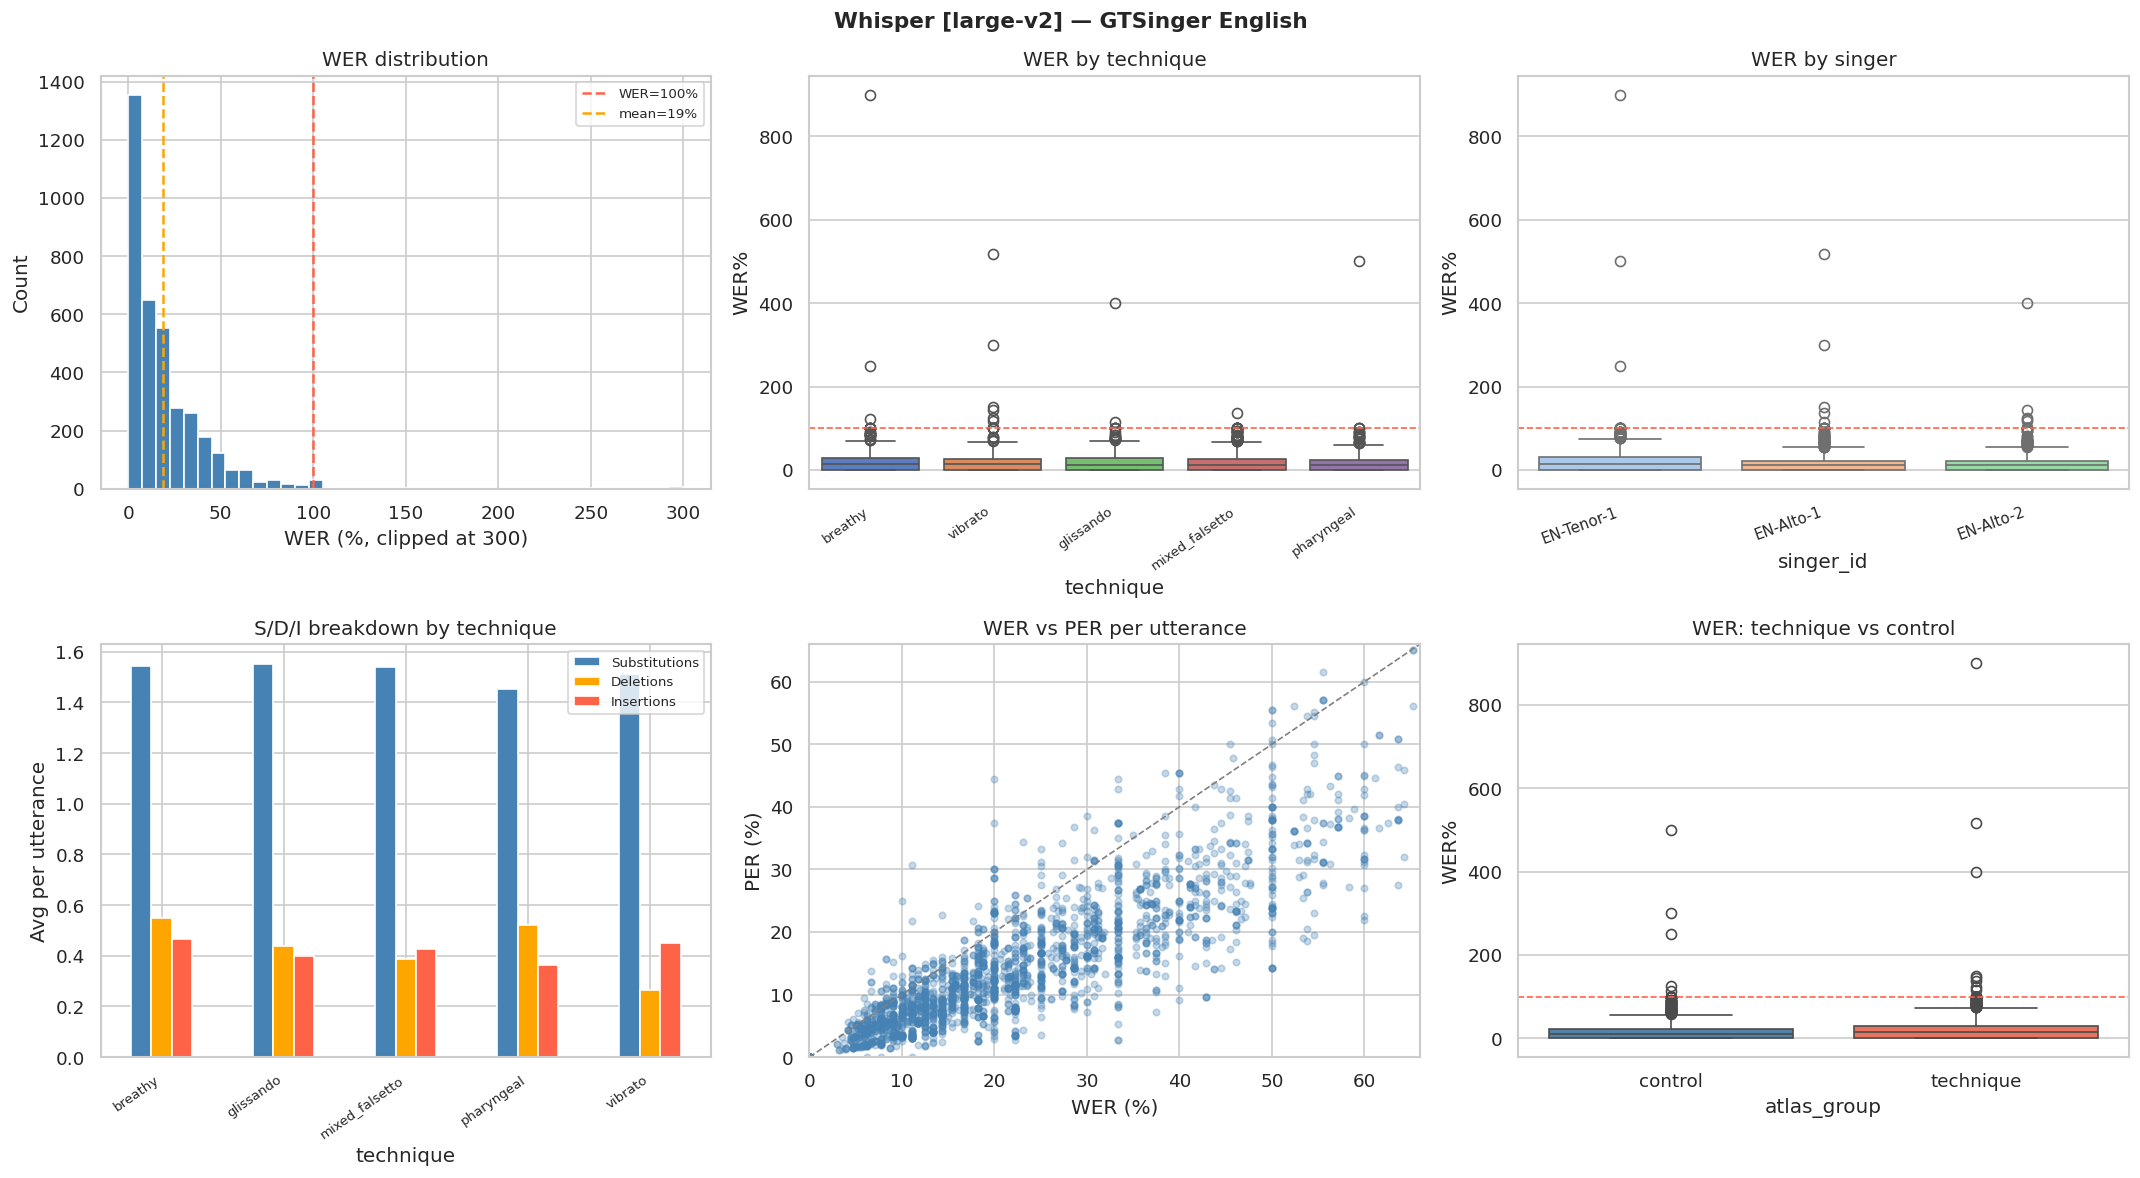

Saved -> whisper_large_v2_plots.png


/tmp/ipykernel_1784/1718712752.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="technique", y="WER%", order=order, ax=ax, palette="muted")
/tmp/ipykernel_1784/1718712752.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
/tmp/ipykernel_1784/1718712752.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="singer_id", y="WER%", order=order, ax=ax, palette="pastel")
/tmp/ipykernel_1784/1718712752.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or

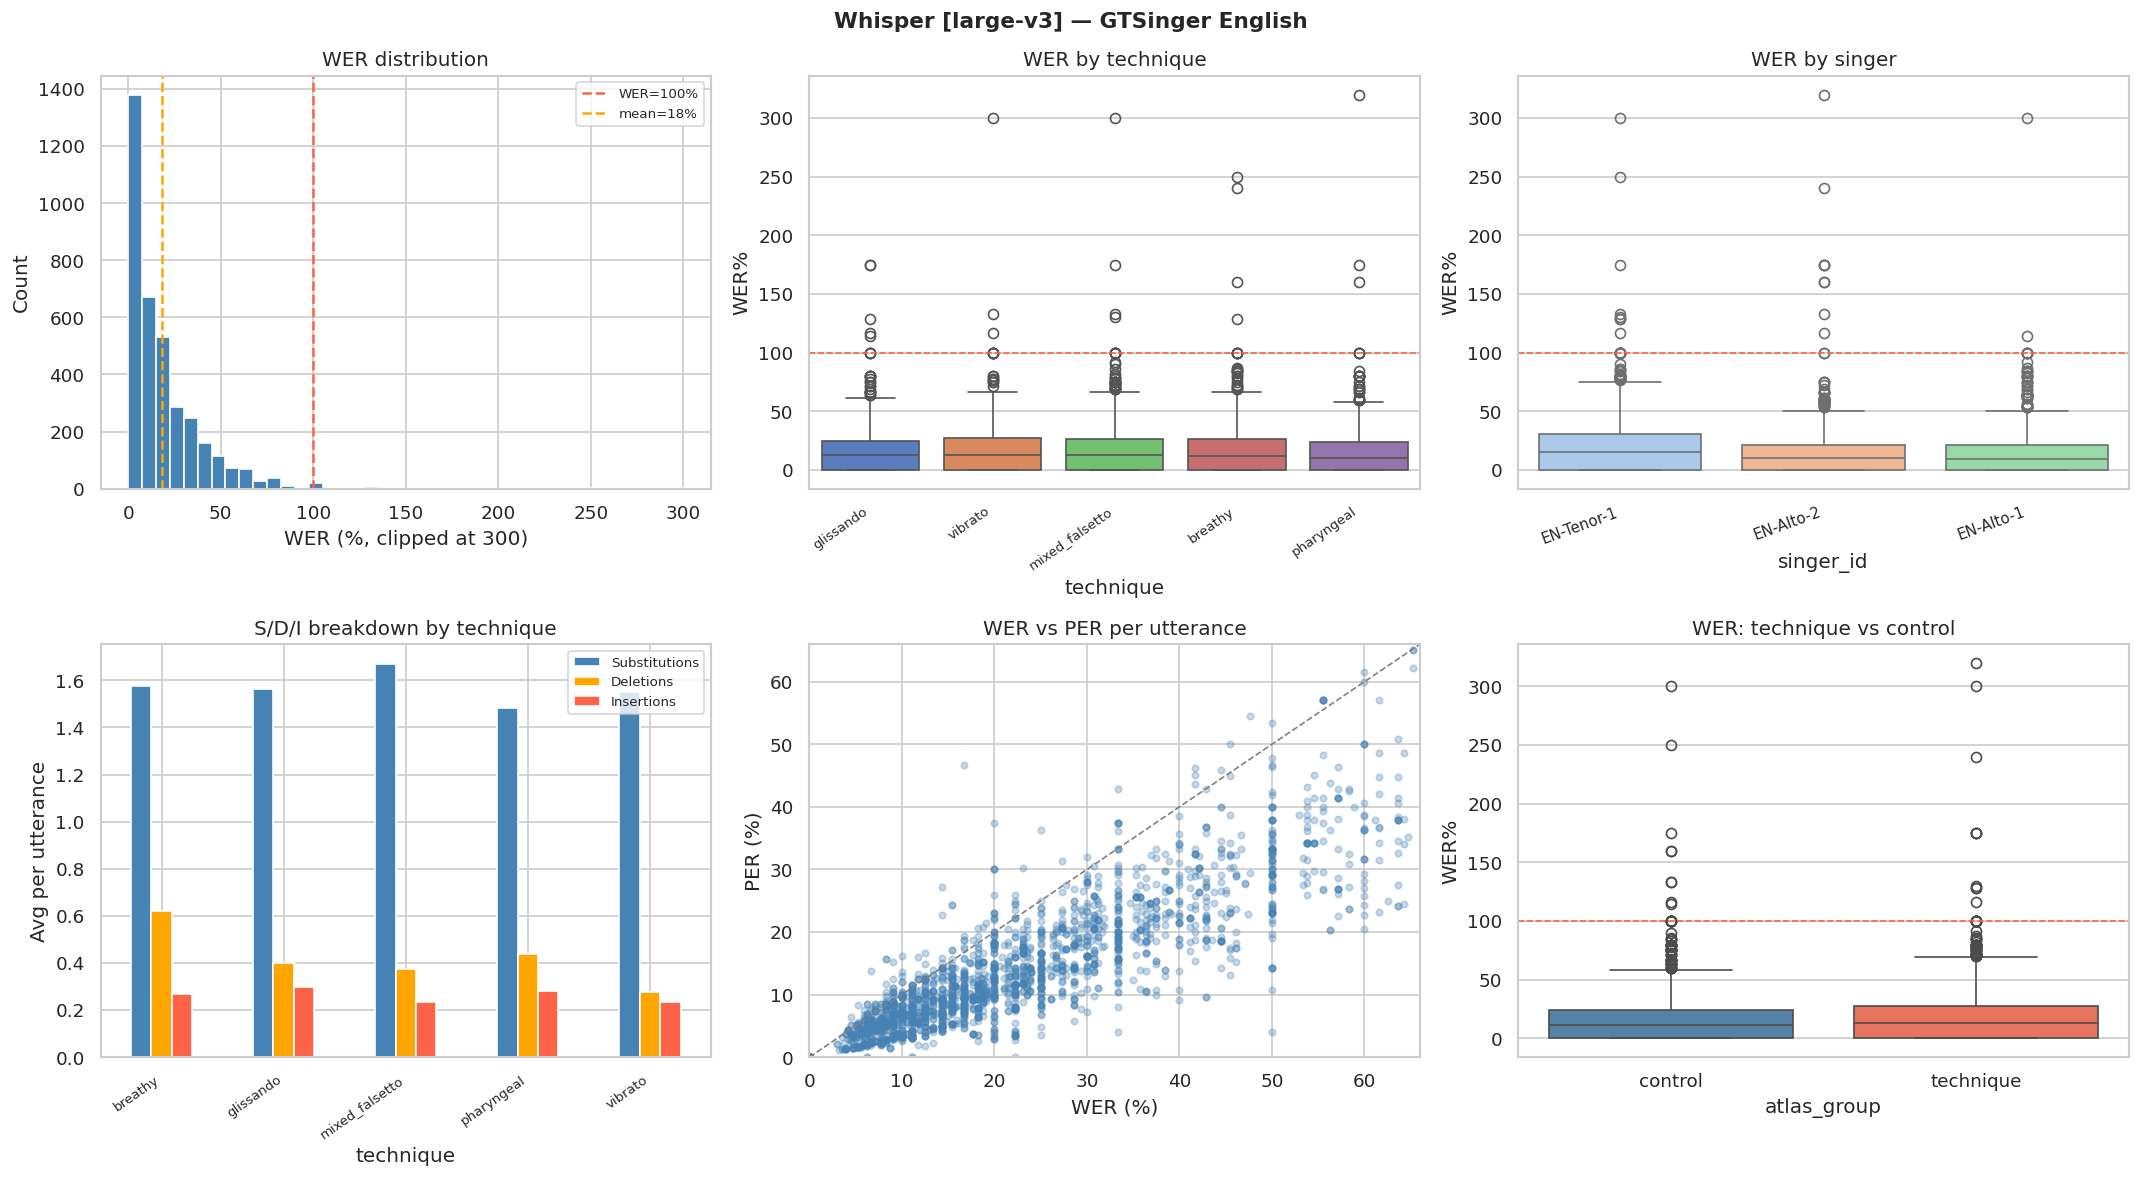

Saved -> whisper_large_v3_plots.png


In [16]:
def plot_whisper(df: pd.DataFrame, model_name: str):
    d = df[df["model"] == model_name].dropna(subset=["wer"]).copy()
    d["WER%"] = d["wer"]*100
    d["PER%"] = d["per"]*100

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Whisper [{model_name}] — GTSinger English", fontsize=13, fontweight="bold")

    # WER distribution
    ax = axes[0,0]
    ax.hist(d["WER%"].clip(upper=300), bins=40, color="steelblue", edgecolor="white")
    ax.axvline(100, color="tomato", ls="--", lw=1.5, label="WER=100%")
    ax.axvline(d["WER%"].mean(), color="orange", ls="--", lw=1.5,
               label=f"mean={d['WER%'].mean():.0f}%")
    ax.set(xlabel="WER (%, clipped at 300)", ylabel="Count", title="WER distribution")
    ax.legend(fontsize=8)

    # WER by technique
    ax = axes[0,1]
    order = d.groupby("technique")["WER%"].median().sort_values(ascending=False).index
    sns.boxplot(data=d, x="technique", y="WER%", order=order, ax=ax, palette="muted")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
    ax.axhline(100, color="tomato", ls="--", lw=1)
    ax.set(title="WER by technique")

    # WER by singer
    ax = axes[0,2]
    order = d.groupby("singer_id")["WER%"].median().sort_values(ascending=False).index
    sns.boxplot(data=d, x="singer_id", y="WER%", order=order, ax=ax, palette="pastel")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
    ax.axhline(100, color="tomato", ls="--", lw=1)
    ax.set(title="WER by singer")

    # S/D/I breakdown by technique
    ax = axes[1,0]
    if "wer_S" in d.columns:
        sdi = d.groupby("technique")[["wer_S","wer_D","wer_I"]].mean()
        sdi.plot(kind="bar", ax=ax, color=["steelblue","orange","tomato"], edgecolor="white")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
        ax.set(ylabel="Avg per utterance", title="S/D/I breakdown by technique")
        ax.legend(["Substitutions","Deletions","Insertions"], fontsize=8)

    # WER vs PER scatter
    ax = axes[1,1]
    ax.scatter(d["WER%"], d["PER%"], alpha=0.3, s=15, color="steelblue")
    lim = max(d["WER%"].quantile(0.95), d["PER%"].quantile(0.95)) * 1.1
    ax.plot([0,lim],[0,lim], "--", color="grey", lw=1)
    ax.set(xlim=(0,lim), ylim=(0,lim), xlabel="WER (%)", ylabel="PER (%)",
           title="WER vs PER per utterance")

    # Technique vs control
    ax = axes[1,2]
    palette = {k:v for k,v in {"technique":"tomato","control":"steelblue"}.items()
               if k in d["atlas_group"].values}
    sns.boxplot(data=d, x="atlas_group", y="WER%", ax=ax, palette=palette)
    ax.axhline(100, color="tomato", ls="--", lw=1)
    ax.set(title="WER: technique vs control")

    plt.tight_layout()
    fname = DRIVE_RESULTS / f"whisper_{model_name.replace('-','_')}_plots.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {fname.name}")


for m in WHISPER_MODELS:
    plot_whisper(df_all, m)

## 12. Qualitative Examples — Best & Worst

In [ ]:
for model_name in WHISPER_MODELS:
    d = df_all[df_all["model"] == model_name].dropna(subset=["wer"]).copy()
    d["WER%"] = (d["wer"]*100).round(1)

    print(f"\n{'='*60}  [{model_name}]")
    print("\n  BEST 5 (lowest WER):")
    for _, row in d.nsmallest(5,"wer").iterrows():
        print(f"  WER={row['WER%']:5.1f}%  [{row['technique']} / {row['atlas_group']}]")
        print(f"    REF: {row['gt_lyrics_clean'][:80]}")
        print(f"    HYP: {normalise_text(str(row['asr_hypothesis']))[:80]}")

    print("\n  WORST 5 (highest WER, min 3 ref words):")
    for _, row in d[d["wer_n_ref"]>2].nlargest(5,"wer").iterrows():
        print(f"  WER={row['WER%']:5.1f}%  [{row['technique']} / {row['atlas_group']}]")
        print(f"    REF: {row['gt_lyrics_clean'][:80]}")
        print(f"    HYP: {normalise_text(str(row['asr_hypothesis']))[:80]}")
        if "wer_S" in row:
            print(f"    S={int(row['wer_S'])}  D={int(row['wer_D'])}  I={int(row['wer_I'])}  ref={int(row['wer_n_ref'])} words")


============================================================  [small]

  BEST 5 (lowest WER):
  WER=  0.0%  [vibrato / control]
    REF: could i be the one youre seeking will i be the one you choose
    HYP: could i be the one youre seeking will i be the one you choose
  WER=  0.0%  [vibrato / control]
    REF: hope will blossom by believing the heart that lies within
    HYP: hope will blossom by believing the heart that lies within
  WER=  0.0%  [vibrato / technique]
    REF: we shall always be as one if you love me for me
    HYP: we shall always be as one if you love me for me
  WER=  0.0%  [vibrato / technique]
    REF: id be sure if i knew that you loved me for me
    HYP: id be sure if i knew that you loved me for me
  WER=  0.0%  [vibrato / technique]
    REF: could i be the one youre seeking will i be the one you choose
    HYP: could i be the one youre seeking will i be the one you choose

  WORST 5 (highest WER, min 3 ref words):
  WER=183.3%  [pharyngeal / technique]
    R

## 13. Cross-Model Comparison: Whisper vs FireRedASR vs wav2vec2

Loads all saved result CSVs from `results/` and produces a unified comparison table and plots.

In [ ]:
# Map filename -> display name
MODEL_FILES = {
    "FireRedASR":     "02fireredasr_singing_WER_PER.csv",
    "wav2vec2-large": "wav2vec2_large_960h__singing_WER_PER.csv",
}
# Add Whisper models dynamically
for m in WHISPER_MODELS:
    MODEL_FILES[f"Whisper-{m}"] = f"whisper_{m.replace('-','_')}__singing_WER_PER.csv"

all_models_df = []
for display_name, fname in MODEL_FILES.items():
    path = DRIVE_RESULTS / fname
    if path.exists():
        d = pd.read_csv(path)
        d["model"] = display_name
        # Normalise column names (FireRedASR/wav2vec use 'group', Whisper uses 'atlas_group')
        if "group" in d.columns and "atlas_group" not in d.columns:
            d["atlas_group"] = d["group"]
        all_models_df.append(d)
        print(f"  Loaded {display_name}: {len(d):,} rows")
    else:
        print(f"  Not found (skipping): {fname}")

if not all_models_df:
    print("No model result files found in DRIVE_RESULTS.")
else:
    combined = pd.concat(all_models_df, ignore_index=True)

    # ── Summary table ──────────────────────────────────────────────────────────
    rows = []
    for model_name in combined["model"].unique():
        d       = combined[combined["model"] == model_name].dropna(subset=["wer"])
        halluc  = (d["wer"] >= 1.0).mean()
        no_h    = d[d["wer"] < 1.0]
        rows.append({
            "model":             model_name,
            "n":                 len(d),
            "WER%":              round(d["wer"].mean()*100, 1),
            "PER%":              round(d["per"].mean()*100, 1),
            "hallucination%":    round(halluc*100, 1),
            "WER% (no halluc)":  round(no_h["wer"].mean()*100, 1),
            "PER% (no halluc)":  round(no_h["per"].mean()*100, 1),
        })

    comp_df = pd.DataFrame(rows).sort_values("WER%")
    comp_df.to_csv(DRIVE_RESULTS / "ALL_MODELS_comparison.csv", index=False)
    print("\nComparison table (sorted by WER):")
    display(comp_df)

  Loaded FireRedASR: 3,646 rows
  Loaded wav2vec2-large: 3,646 rows
  Loaded Whisper-small: 3,646 rows
  Not found (skipping): whisper_large_v2__singing_WER_PER.csv

Comparison table (sorted by WER):


,model,n,WER%,PER%,hallucination%,WER% (no halluc),PER% (no halluc)
2,Whisper-small,3646,25.3,15.4,1.3,23.5,14.5
0,FireRedASR,3646,121.1,111.2,75.0,80.9,74.5
1,wav2vec2-large,3646,124.0,107.3,81.0,87.9,77.8


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=comp_df)

https://docs.google.com/spreadsheets/d/107167Ee45s2uYCx7ox8CoOhhMevKezDAtcKlOh737t0/edit#gid=0


/tmp/ipykernel_4340/221670895.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(halluc_vals.index, rotation=25, ha="right", fontsize=9)


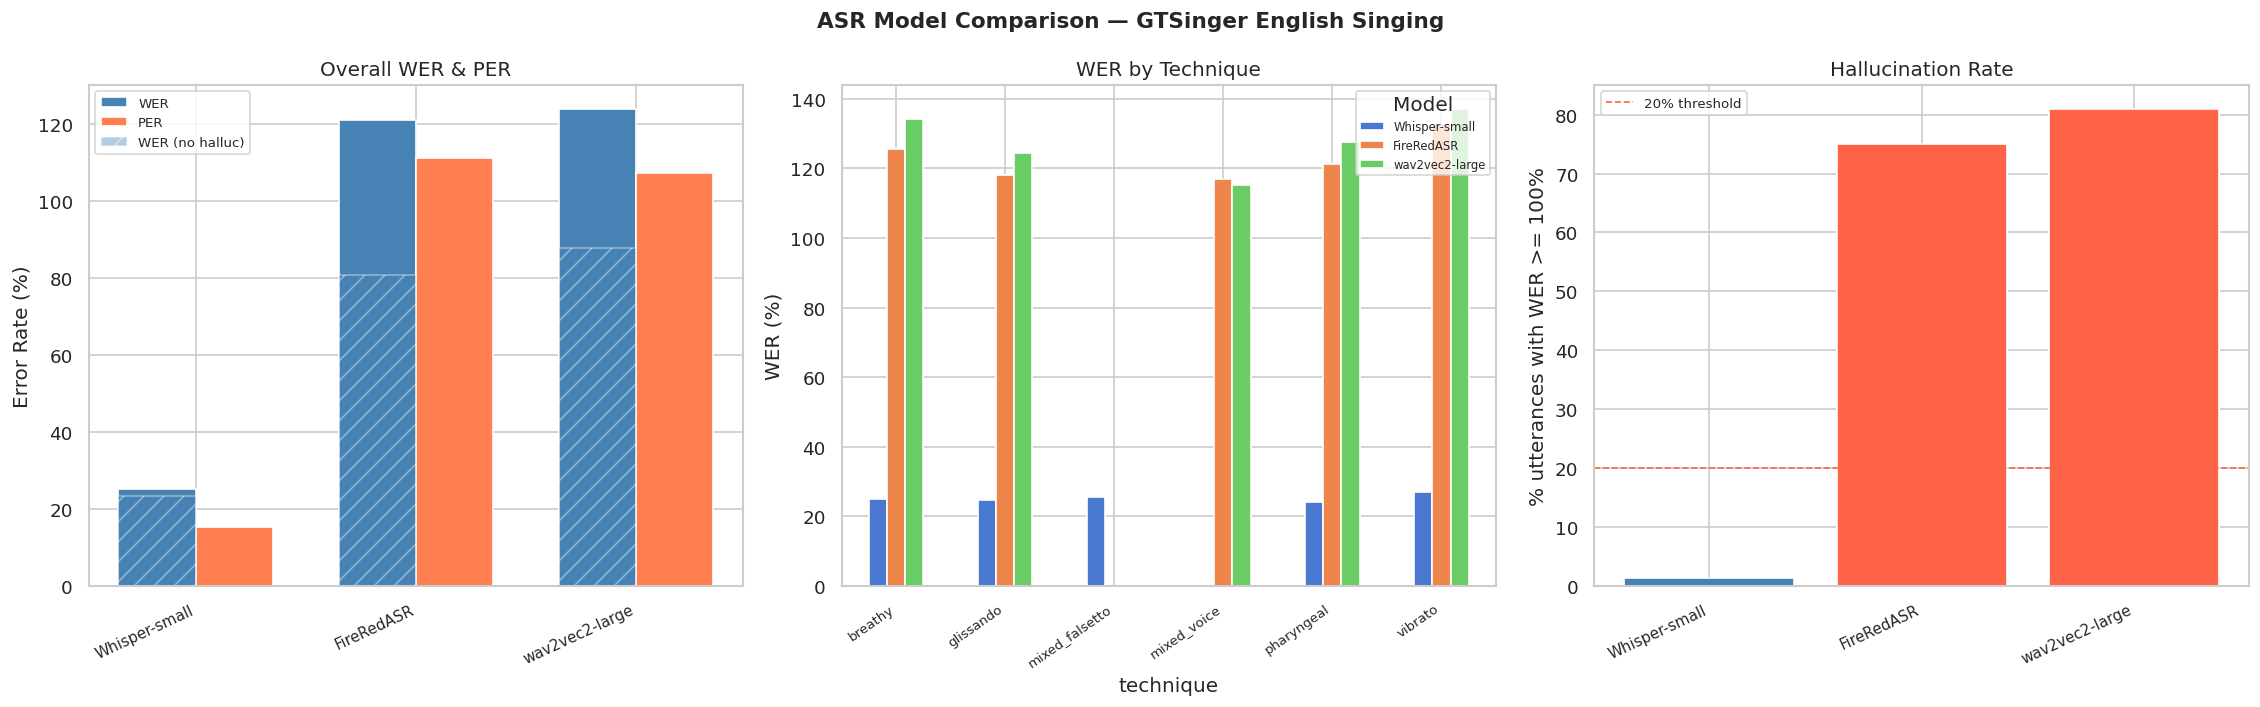

Saved -> ALL_MODELS_comparison_plots.png


In [ ]:
if all_models_df:
    fig, axes = plt.subplots(1, 3, figsize=(19, 6))
    fig.suptitle("ASR Model Comparison — GTSinger English Singing",
                 fontsize=13, fontweight="bold")
    model_order = comp_df["model"].tolist()  # sorted by WER

    # Overall WER & PER bar chart
    ax = axes[0]
    x  = np.arange(len(comp_df))
    w  = 0.35
    ax.bar(x - w/2, comp_df["WER%"],          w, label="WER",         color="steelblue")
    ax.bar(x + w/2, comp_df["PER%"],          w, label="PER",         color="coral")
    ax.bar(x - w/2, comp_df["WER% (no halluc)"], w, label="WER (no halluc)",
           color="steelblue", alpha=0.4, hatch="//")
    ax.set_xticks(x)
    ax.set_xticklabels(comp_df["model"], rotation=25, ha="right", fontsize=9)
    ax.set(ylabel="Error Rate (%)", title="Overall WER & PER")
    ax.legend(fontsize=8)

    # WER by technique (grouped)
    ax = axes[1]
    tech_pivot = (combined.groupby(["model","technique"])["wer"]
                  .mean().unstack() * 100)
    # Reorder rows by model_order
    tech_pivot = tech_pivot.reindex([m for m in model_order if m in tech_pivot.index])
    tech_pivot.T.plot(kind="bar", ax=ax, edgecolor="white")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
    ax.set(ylabel="WER (%)", title="WER by Technique")
    ax.legend(title="Model", fontsize=7, loc="upper right")

    # Hallucination rate
    ax = axes[2]
    halluc_vals = comp_df.set_index("model")["hallucination%"].reindex(model_order).dropna()
    colors      = [("tomato" if v > 20 else "steelblue") for v in halluc_vals]
    ax.bar(halluc_vals.index, halluc_vals.values, color=colors, edgecolor="white")
    ax.set_xticklabels(halluc_vals.index, rotation=25, ha="right", fontsize=9)
    ax.set(ylabel="% utterances with WER >= 100%", title="Hallucination Rate")
    ax.axhline(20, color="tomato", ls="--", lw=1, label="20% threshold")
    ax.legend(fontsize=8)

    plt.tight_layout()
    fname = DRIVE_RESULTS / "ALL_MODELS_comparison_plots.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {fname.name}")